
Nama : Aidan Predella N  
NIM : 4222301077


## Deep Learning Using CNN

Nama: Aidan Predella N

**Dataset:**
https://www.kaggle.com/datasets/farzadnekouei/trash-type-image-dataset

### Objective
Membangun model Convolutional Neural Network (CNN) untuk mengklasifikasikan jenis sampah berdasarkan gambar sehingga dapat membantu proses pemilahan sampah di lingkungan kampus.

## Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## Membaca Dataset

In [2]:
dataset_path = "TrashType_Image_Dataset"

classes = sorted(os.listdir(dataset_path))

print("Kategori Sampah:")
print(classes)

Kategori Sampah:
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## Jumlah Data Tiap Kelas

In [3]:
jumlah_per_kelas = {}

for kelas in classes:

    path_folder = os.path.join(
        dataset_path,
        kelas
    )

    jumlah_per_kelas[kelas] = len(
        os.listdir(path_folder)
    )

df_jumlah = pd.DataFrame(
    jumlah_per_kelas.items(),
    columns=["Class","Total"]
)

df_jumlah

,Class,Total
0,cardboard,403
1,glass,501
2,metal,410
3,paper,594
4,plastic,482
5,trash,137


## Grafik Distribusi Dataset

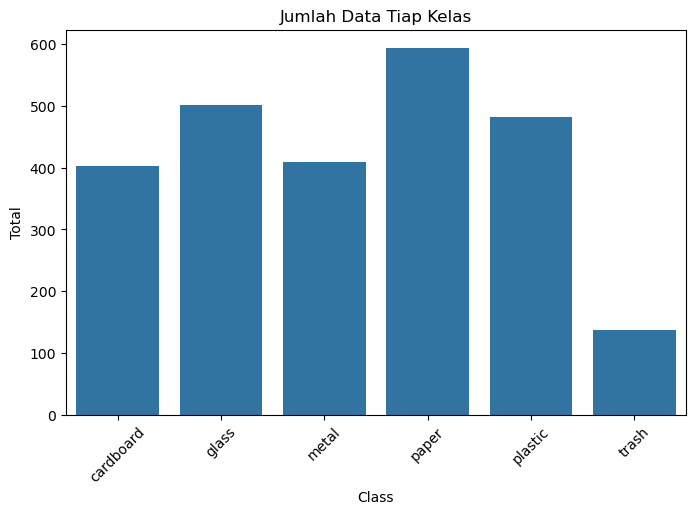

In [4]:
class_count = {}

for cls in classes:
    folder = os.path.join(dataset_path, cls)
    class_count[cls] = len(os.listdir(folder))

df_count = pd.DataFrame(
    class_count.items(),
    columns=["Class","Total"]
)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Class",
    y="Total",
    data=df_count
)

plt.title(
    "Jumlah Data Tiap Kelas"
)

plt.xticks(
    rotation=45
)

plt.show()

## Persentase Data Tiap Kelas

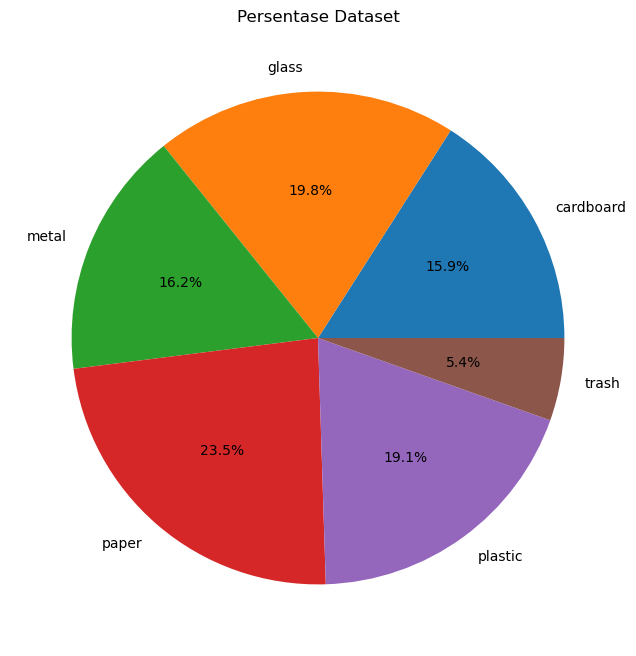

In [5]:
plt.figure(figsize=(8,8))

plt.pie(
    x=df_count["Total"],
    labels=df_count["Class"],
    autopct="%1.1f%%"
)

plt.title(
    "Persentase Dataset"
)

plt.show()

## Menampilkan Contoh Gambar

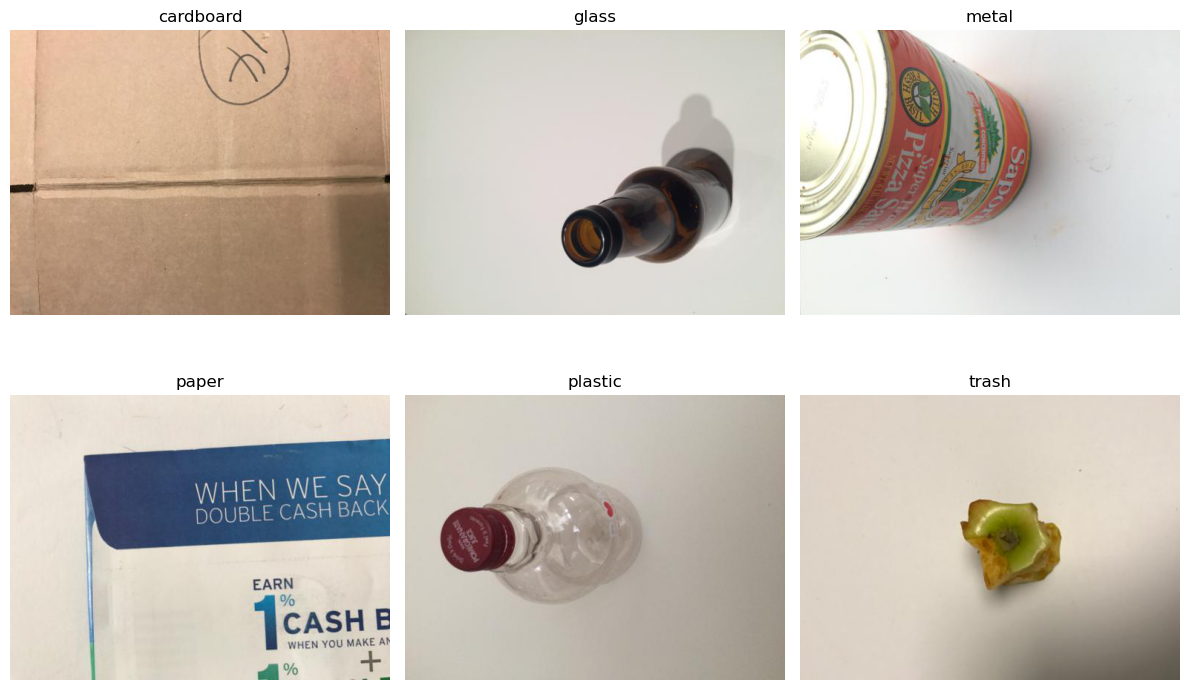

In [6]:
plt.figure(figsize=(12,8))

for idx, kelas in enumerate(classes):

    path_folder = os.path.join(
        dataset_path,
        kelas
    )

    nama_gambar = os.listdir(path_folder)[0]

    path_gambar = os.path.join(
        path_folder,
        nama_gambar
    )

    gambar = plt.imread(path_gambar)

    plt.subplot(
        2,
        3,
        idx+1
    )

    plt.imshow(gambar)

    plt.title(kelas)

    plt.axis("off")

plt.tight_layout()

plt.show()

## Preprocessing Data

In [7]:
data = []
labels = []

IMG_SIZE = 64

def resize_image(img, size):
    h, w = img.shape[:2]
    row_idx = np.linspace(0, h-1, size).astype(int)
    col_idx = np.linspace(0, w-1, size).astype(int)
    return img[row_idx][:, col_idx]

for label, cls in enumerate(classes):

    folder = os.path.join(
        dataset_path,
        cls
    )

    for img_name in os.listdir(folder):

        try:

            img_path = os.path.join(
                folder,
                img_name
            )

            img = plt.imread(img_path)

            img = img[:, :, :3]

            img = resize_image(img, IMG_SIZE)

            data.append(
                img.flatten()
            )

            labels.append(
                label
            )

        except Exception as e:
            print(img_name, "->", e)

X = np.array(data)

y = np.array(labels)

print(X.shape)

print(y.shape)

(2527, 12288)
(2527,)


## Split Dataset

In [8]:
print("Jumlah data sebelum split:", X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(
    "Training:",
    X_train.shape
)

print(
    "Testing:",
    X_test.shape
)

Jumlah data sebelum split: (2527, 12288) (2527,)
Training: (2021, 12288)
Testing: (506, 12288)


## Training Random Forest

In [9]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Prediksi Data Testing

In [10]:
y_pred = rf.predict(
    X_test
)

## Accuracy Model

In [11]:
acc = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    round(
        acc*100,
        2
    ),
    "%"
)

Accuracy: 67.59 %


## Classification Report

In [12]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=classes
    )
)

              precision    recall  f1-score   support

   cardboard       0.69      0.74      0.71        81
       glass       0.59      0.66      0.62       100
       metal       0.64      0.52      0.58        82
       paper       0.73      0.85      0.79       119
     plastic       0.69      0.62      0.65        97
       trash       0.80      0.44      0.57        27

    accuracy                           0.68       506
   macro avg       0.69      0.64      0.65       506
weighted avg       0.68      0.68      0.67       506



## Confusion Matrix

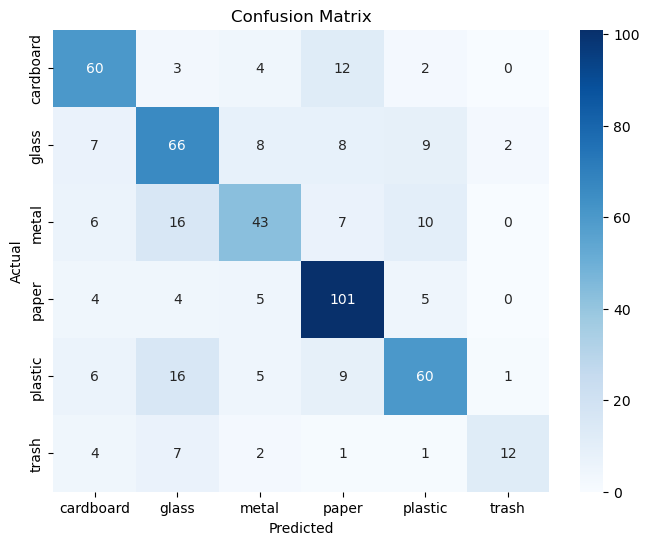

In [13]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(
    figsize=(8,6)
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

## Distribusi Hasil Prediksi

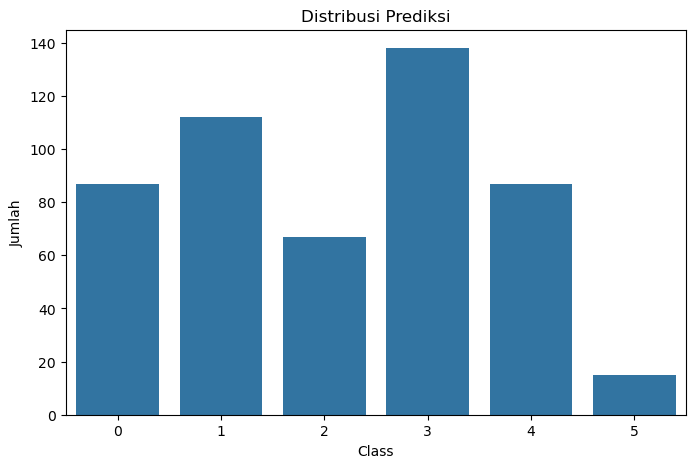

In [14]:
pred_count = pd.Series(
    y_pred
).value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
    x=pred_count.index,
    y=pred_count.values
)

plt.title(
    "Distribusi Prediksi"
)

plt.xlabel(
    "Class"
)

plt.ylabel(
    "Jumlah"
)

plt.show()

## Menampilkan Hasil Prediksi

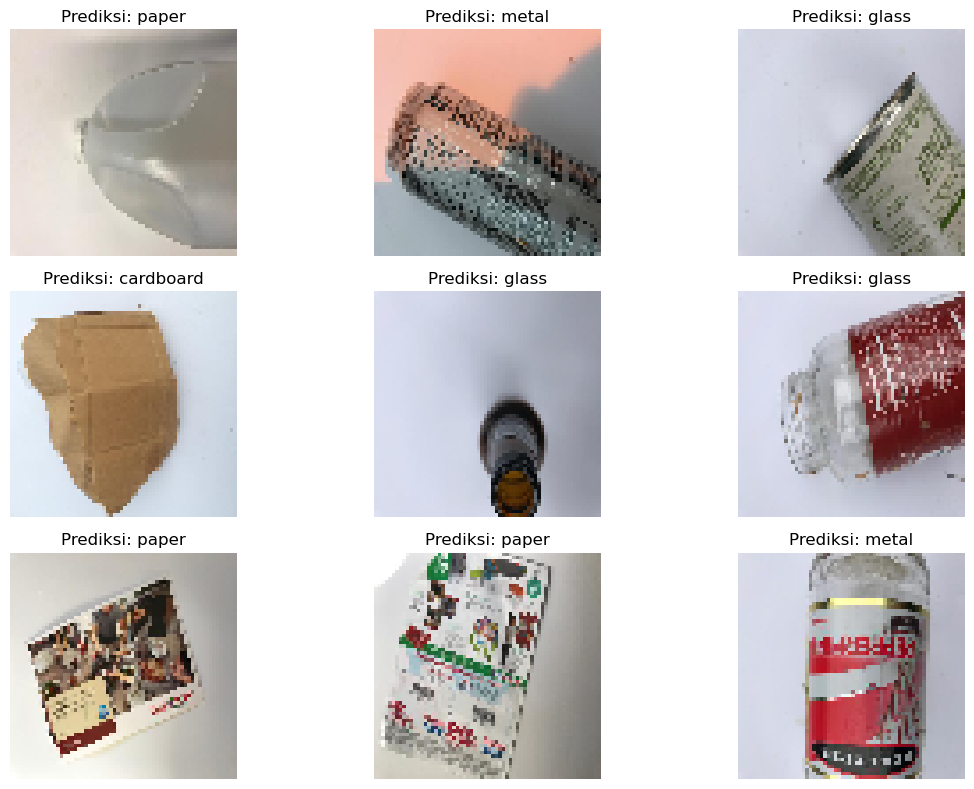

In [15]:
plt.figure(figsize=(12,8))

for i in range(9):

    img = X_test[i].reshape(
        IMG_SIZE,
        IMG_SIZE,
        3
    )

    pred = rf.predict(
        [X_test[i]]
    )[0]

    plt.subplot(
        3,
        3,
        i+1
    )

    plt.imshow(img)

    plt.title(
        f"Prediksi: {classes[pred]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

## Analisis

1. Dataset terdiri dari 6 kategori sampah.
2. Kelas paper memiliki jumlah data terbanyak.
3. Kelas trash memiliki jumlah data paling sedikit.
4. Random Forest mampu mempelajari pola visual dari gambar sampah.
5. Kesalahan klasifikasi umumnya terjadi pada kelas yang memiliki karakteristik visual mirip seperti paper dan cardboard.
6. Model menghasilkan performa yang cukup baik untuk klasifikasi gambar sederhana.

## Kesimpulan

Pada proyek ini telah dibangun model klasifikasi gambar menggunakan algoritma Random Forest untuk mendeteksi jenis sampah.

Model berhasil mengklasifikasikan gambar ke dalam kategori:

- Cardboard
- Glass
- Metal
- Paper
- Plastic
- Trash

Berdasarkan hasil evaluasi, model menunjukkan performa yang cukup baik dalam mengenali berbagai jenis sampah dan dapat digunakan sebagai dasar sistem pemilahan sampah otomatis di lingkungan kampus.

Untuk penelitian selanjutnya dapat digunakan metode Deep Learning seperti CNN untuk memperoleh akurasi yang lebih tinggi.